In [1]:
from langchain.chat_models import init_chat_model
from pydantic import BaseModel , Field

model = init_chat_model("google_genai:gemini-3-flash-preview")


class GraphSchema(BaseModel):
    title:str = Field(..., description="The title of the post")
    insta:str = Field(..., description="The post content for instagram post.")
    twitter:str = Field(..., description="The post content for instagram post.")

In [15]:
def insta_node(state:GraphSchema):
    title=state.title
    post = model.invoke(f"Genereate post for insta on {title}")
    
    return {"insta" : post}

def twitter_node(state:GraphSchema):
    title=state.title
    post = model.invoke(f"Genereate post for twitter on {title}")
    
    return {"twitter" : post}

In [16]:
from langgraph.graph import StateGraph,END,START

graph = StateGraph(GraphSchema)
graph.add_node("insta_node",insta_node)
graph.add_node("twitter_node",twitter_node)

graph.add_edge(START,"insta_node")
graph.add_edge(START,"twitter_node")
graph.add_edge("insta_node",END)
graph.add_edge("twitter_node",END)

graph = graph.compile()

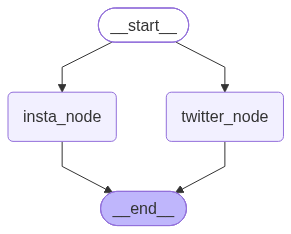

In [17]:
graph

In [18]:
graph.invoke({
    "title":"Population",
    "insta":"",
    "twitter":""
})

{'title': 'Population',
 'insta': AIMessage(content=[{'type': 'text', 'text': 'To give you the best post, I’ve broken these down by "vibe"—choose the one that fits your page’s style best!\n\n### Option 1: The "Thought-Provoking" Post\n**Visual Idea:** A high-quality photo of a crowded city street at night or a beautiful shot of the Earth from space.\n\n**Caption:**\n8 Billion people. 🌍 \n\nIt’s hard to wrap your head around that number. Every single person has a story, a family, and a dream. As our global family grows, so does our responsibility to each other and to the planet we call home. \n\nHow do we ensure a sustainable future for the next billion? It starts with education, resource management, and a little more empathy. 🤝✨\n\nWhat’s one thing you think we need more of in a world of 8 billion? 👇\n\n#WorldPopulation #8Billion #GlobalCitizens #Sustainability #Humanity #OurPlanet #FutureThinking\n\n---\n\n### Option 2: The "Environmental/Sustainability" Post\n**Visual Idea:** A split